In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

archivo = pd.read_excel('LAB7.xlsx', sheet_name='Sheet1')
df = pd.DataFrame(archivo)
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,voltaje constante,R2,VR1,VR2,I,Unnamed: 9,corriente constante,R22,I1,I2,I3
0,NaN,NaN,NaN,NaN,NaN,10,8.600,0.882,0.090,NaN,NaN,10,0.09,0.083,0.008
1,R1,100 omega,NaN,NaN,NaN,20,8.070,1.645,0.082,NaN,NaN,20,0.09,0.077,0.014
2,R3,100 omega,NaN,NaN,NaN,30,7.430,2.185,0.076,NaN,NaN,30,0.09,0.071,0.019
3,NaN,NaN,NaN,NaN,NaN,40,6.770,2.751,0.069,NaN,NaN,40,0.09,0.067,0.025
4,NaN,NaN,NaN,NaN,NaN,50,6.380,3.221,0.065,NaN,NaN,50,0.09,0.063,0.029
5,NaN,NaN,NaN,NaN,NaN,60,6.030,3.656,0.061,NaN,NaN,60,0.09,0.058,0.033
6,NaN,NaN,NaN,NaN,NaN,70,5.700,4.031,0.058,NaN,NaN,70,0.09,0.055,0.036
7,NaN,NaN,NaN,NaN,NaN,80,5.360,4.361,0.055,NaN,NaN,80,0.09,0.052,0.040
8,NaN,NaN,NaN,NaN,NaN,90,5.100,4.640,0.052,NaN,NaN,90,0.09,0.048,0.042
9,NaN,NaN,NaN,NaN,NaN,100,4.850,4.900,0.050,NaN,NaN,100,0.09,0.047,0.045


<>:21: SyntaxWarning: invalid escape sequence '\O'
<>:21: SyntaxWarning: invalid escape sequence '\O'
C:\Users\andy\AppData\Local\Temp\ipykernel_8268\4248470456.py:21: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('Resistencia $R_2$ ($\Omega$)')


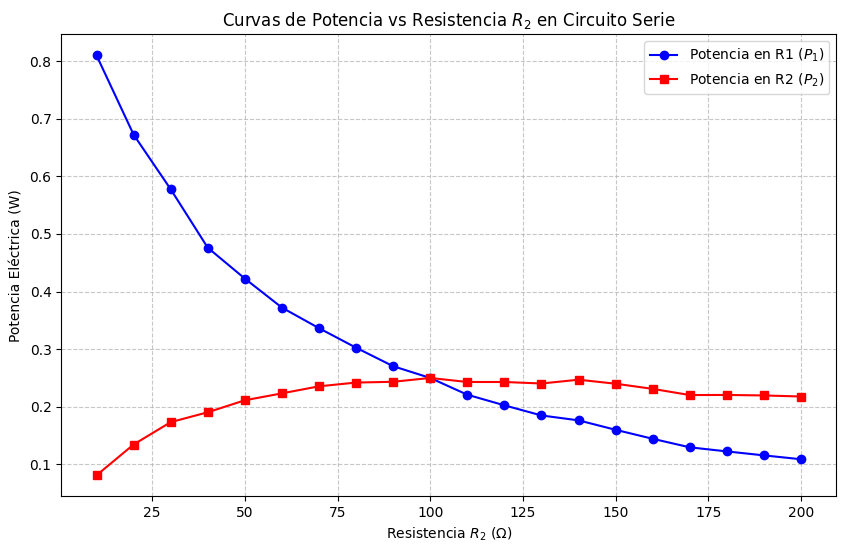

In [3]:
R2 = df["R2"]
VR1 = df["VR1"]
VR2 = df["VR2"]
I = df["I"]
R22 = R2
I1 = 0.09
I2 = df["I2"]
I3 = df["I3"]

PR1 = I**2 * 100
PR2 = I**2 * R2

plt.figure(figsize=(10, 6))

# 4. Trazado de las curvas
# Se emplean marcadores ('o', 's') para distinguir los puntos discretos medidos en el laboratorio
plt.plot(R2, PR1, label='Potencia en R1 ($P_1$)', marker='o', linestyle='-', color='blue')
plt.plot(R2, PR2, label='Potencia en R2 ($P_2$)', marker='s', linestyle='-', color='red')

# 5. Configuración de ejes y elementos visuales
plt.xlabel('Resistencia $R_2$ ($\Omega$)')
plt.ylabel('Potencia Eléctrica (W)')
plt.title('Curvas de Potencia vs Resistencia $R_2$ en Circuito Serie')

# La malla es crucial aquí para ubicar gráficamente el punto de cruce
plt.grid(True, linestyle='--', alpha=0.7) 
plt.legend()

# 6. Despliegue
plt.show()



<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
C:\Users\andy\AppData\Local\Temp\ipykernel_8268\133069756.py:12: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('Resistencia $R_2$ ($\Omega$)')
C:\Users\andy\AppData\Local\Temp\ipykernel_8268\133069756.py:15: SyntaxWarning: invalid escape sequence '\O'
  plt.axvline(x=100, color='gray', linestyle='--', alpha=0.7, label='Punto de simetría ($R_2 = 100 \Omega$)')


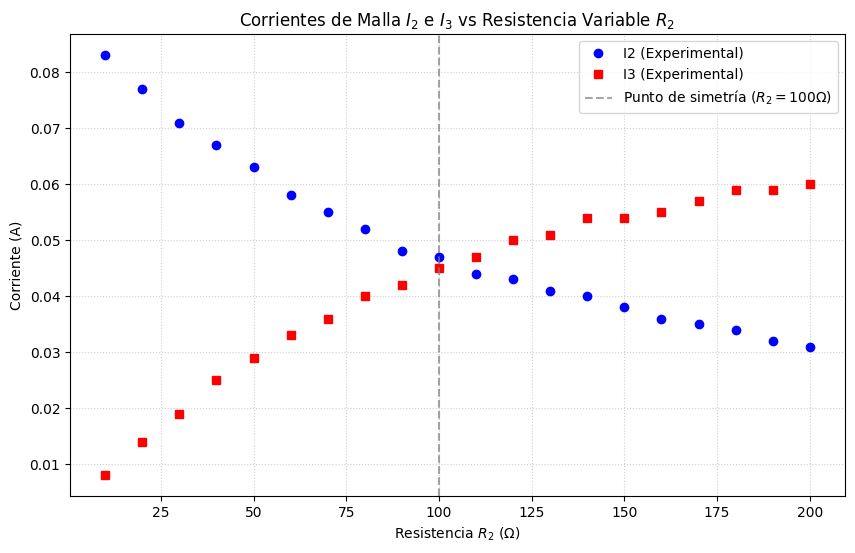

In [4]:
I2_teo = I1 * (I3 / (R2 + I3))
I3_teo = I1 * (R2 /(R2 + I3)) 

plt.figure(figsize=(10, 6))

# Trazado de datos experimentales (puntos)
plt.plot(R2, I2, 'bo', label='I2 (Experimental)')
plt.plot(R2, I3, 'rs', label='I3 (Experimental)')


# Configuración de la gráfica
plt.xlabel('Resistencia $R_2$ ($\Omega$)')
plt.ylabel('Corriente (A)')
plt.title('Corrientes de Malla $I_2$ e $I_3$ vs Resistencia Variable $R_2$')
plt.axvline(x=100, color='gray', linestyle='--', alpha=0.7, label='Punto de simetría ($R_2 = 100 \Omega$)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

In [13]:
I1 = 0.09            # Corriente constante del circuito paralelo (A)
R3 = 100.0           # Resistencia fija (Ohms)
delta = 0.001

denominador = (R2 + R3)
denominador_cuadrado = denominador**2

delta_PR1 = np.sqrt((2*I*R3 * delta)**2 + (I**2 * delta)**2)
delta_PR2 = np.sqrt((2*I*R3 * delta)**2 + (I**2 * delta)**2)


error_R2_R3 = (- (I1 * R3) / denominador_cuadrado)**2 + ((I1 * R2) / denominador_cuadrado)**2

# Fórmula ΔI2: Propagación completa
delta_I2 = delta * np.sqrt( (R3 / denominador)**2 + error_R2_R3 )

# Fórmula ΔI3: Propagación completa
delta_I3 = delta * np.sqrt( (R2 / denominador)**2 + error_R2_R3 )

df["delta_PR1"] = delta_PR1
df["delta_PR2"] = delta_PR2
df["delta_I2"] = delta_I2
df["delta_I3"] = delta_I3


In [14]:
print(df[["R2", "delta_PR1", "delta_PR2", "delta_I2", "delta_I3"]]) 


     R2  delta_PR1  delta_PR2  delta_I2  delta_I3
0    10     0.0180     0.0180  0.000909  0.000091
1    20     0.0164     0.0164  0.000833  0.000167
2    30     0.0152     0.0152  0.000769  0.000231
3    40     0.0138     0.0138  0.000714  0.000286
4    50     0.0130     0.0130  0.000667  0.000333
5    60     0.0122     0.0122  0.000625  0.000375
6    70     0.0116     0.0116  0.000588  0.000412
7    80     0.0110     0.0110  0.000556  0.000444
8    90     0.0104     0.0104  0.000526  0.000474
9   100     0.0100     0.0100  0.000500  0.000500
10  110     0.0094     0.0094  0.000476  0.000524
11  120     0.0090     0.0090  0.000455  0.000545
12  130     0.0086     0.0086  0.000435  0.000565
13  140     0.0084     0.0084  0.000417  0.000583
14  150     0.0080     0.0080  0.000400  0.000600
15  160     0.0076     0.0076  0.000385  0.000615
16  170     0.0072     0.0072  0.000370  0.000630
17  180     0.0070     0.0070  0.000357  0.000643
18  190     0.0068     0.0068  0.000345  0.000655


In [24]:
rint = (200*I[9] - 100 * I[0]) / (I[0] - I[9])

deltar = (0.09 * np.sqrt(I[0]**2 + I[9]**2)) / (I[0] - I[9])**2

In [29]:
electromotriz = I[0] * (110 + rint)

delta_epsilon = (0.09 / (I[0] - I[9])**2) * np.sqrt(I[0]**4 + I[9]**4)

delta_epsilon

0.4768328126817618

In [ ]:
for i in range(len(delta_PR1)):
    
    print(f" \pm {delta_PR1[i]:.3f} &", end=" ")
    
    if (i+1) % 5 == 0: 
        print()

 \pm 0.018 &  \pm 0.016 &  \pm 0.015 &  \pm 0.014 &  \pm 0.013 & 
 \pm 0.012 &  \pm 0.012 &  \pm 0.011 &  \pm 0.010 &  \pm 0.010 & 
 \pm 0.009 &  \pm 0.009 &  \pm 0.009 &  \pm 0.008 &  \pm 0.008 & 
 \pm 0.008 &  \pm 0.007 &  \pm 0.007 &  \pm 0.007 &  \pm 0.007 & 


<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
C:\Users\andy\AppData\Local\Temp\ipykernel_8268\96577967.py:3: SyntaxWarning: invalid escape sequence '\p'
  print(f" \pm {delta_PR1[i]:.3f} &", end=" ")
